# Logistic Regression - Einstieg

2026-06-16 ug Version 1.5 

---
Referenzen:

[Logistic Regression in Python](https://realpython.com/logistic-regression-python/)


---
### Standard Pakete laden

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

---
### Darstellung der Plots im "Seaborn"-Design:

Mit der Funktion [`seaborn.set_theme()`](https://seaborn.pydata.org/generated/seaborn.set_theme.html) lassen sich mehrere Optionen zur Darstellung der Plots umstellen.

In [2]:
sns.set_theme()

-----
### Sehr einfaches Beispiel

Es soll untersucht werden, ob ein bestimmtes Buch vorwiegend von der älteren Generation gelesen wird.

Dazu wurden an einen Tag Personen befragt, ob sie das Buch kennen und wie alt sie sind.

Der Datensatz enthält folgende zwei Variablen:
- "_Alter_": Alter der Person in Jahren (kontinuierliche, quantitative Größe) und
- "_Gelesen_":  1: Buch wurde gelesen und 0: das Buch wurde nicht gelesen (diskrete, qualitative Größe)

Wir nehmen die Variable "_Gelesen_" als abhängige Variable und die Variable "_Alter" als unabhängige Variable an. 

Datensatz:

In [3]:
Alter   = [15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]
Gelesen = [ 0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1]

Wir erstellen zunächst einen Scatterplot der Daten mit der abhängigen Variablen "_Gelesen_" auf der y-Achse und der unabhängigen Variablen "_Alter" auf der y-Achse 

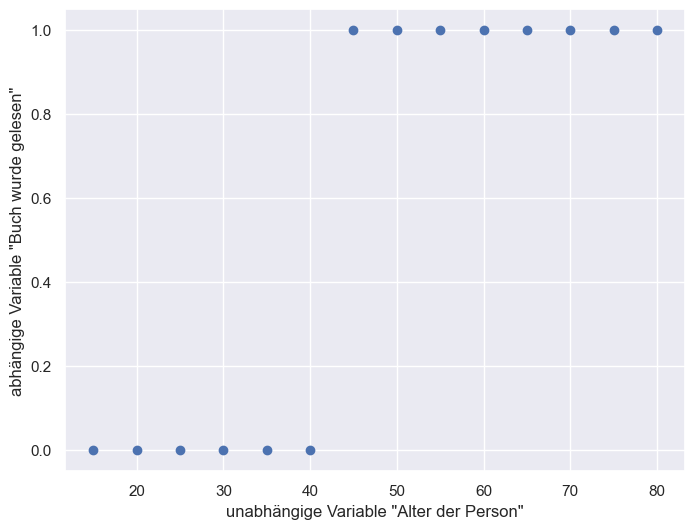

In [4]:
plt.figure(figsize=(8,6))
plt.scatter(Alter,Gelesen)
plt.xlabel('unabhängige Variable "Alter der Person"')
plt.ylabel('abhängige Variable "Buch wurde gelesen"');

---
### Versuch den Zusammenhang zwischen den Variablen durch eine _lineare Regression_ zu bestimmen

<Axes: xlabel='Alter', ylabel='Gelesen'>

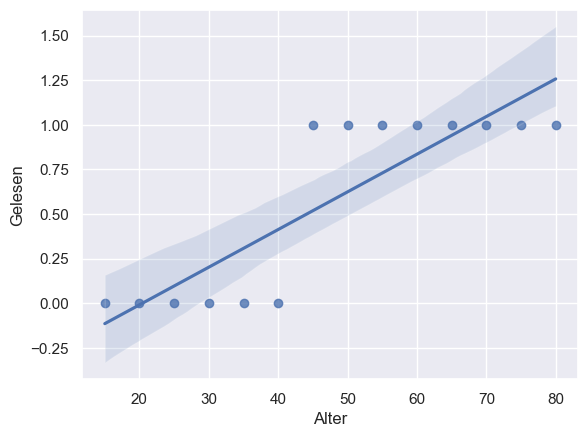

In [5]:
df = pd.DataFrame(data={'Alter':Alter,'Gelesen':Gelesen})
sns.regplot(data=df,x='Alter',y='Gelesen')

Das funktioniert nicht so richtig.

Was machen wir mit sehr großen positiven und negativen Werten?

Was wir bräuchten wäre eine mathematische Funktion, die zwischen 0 und 1 begrenzt ist, und damit eine Zugehörigkeit-Funktion oder Wahrscheinlichkeit betrachtet werden kann.

Lösung: _**Sigmoid function**_ - https://en.wikipedia.org/wiki/Sigmoid_function sind S-förmige Kurven, die diese Eigenschaften besitzen.

Wir nutzen hier die _**Logistische Funktion**_ https://en.wikipedia.org/wiki/Logistic_function:

$$
f(x) = \frac{1}{1+e^{-k(x-x_0)}} = \frac{e^{k(x-x_0)}}{1+e^{k(x-x_0)}}
$$

mit 
- $x_0$ als Wendepunkt der _Logistische Funktion_ in x-Richtung und 
- $k$ logistische Wachstumsrate oder Steigung der _Logistische Funktion_

Wir werden als nächstes die _Logistische Funktion_ für unterschiedliche Werte von $k$ plotten:

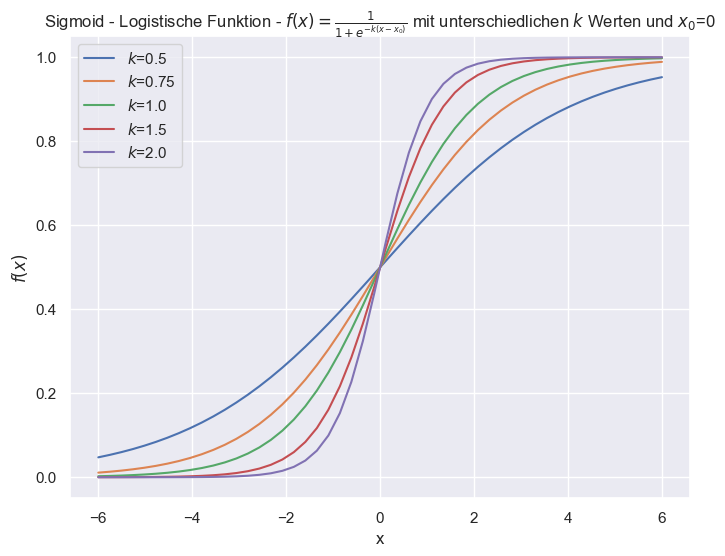

In [6]:
def LogisticFkt(x, k=1,x0=0):
    return 1/(1+np.exp(-k*(x-x0)))

x = np.linspace(-6,6)

x0 = 0

plt.figure(figsize=(8,6))
for k in [0.5,0.75,1.0,1.5,2.0]:
    plt.plot(x,LogisticFkt(x,k=k,x0=x0),  label=f'$k$={k}')

# unterschiedliche x0 Werte -> Plot wird aber dann zu überladen 
#plt.plot(x,LogisticFkt(x,k=1.0,x0=-1),  label=f'$k$=1.0; $x_0$=-1')

plt.xlabel('x')
plt.ylabel('$f(x)$')
plt.legend()
plt.title(r'Sigmoid - Logistische Funktion - $f(x) = \frac{1}{1+e^{-k(x-x_0)}}$' + f' mit unterschiedlichen $k$ Werten und $x_0$={x0}');

Je größer der Paramter $k$, desto steiler verläuft die Kurve von 0 nach 1. 

Unsere Modellvorstellung:

In Abhängigkeit der unabhängigen Variablen $x$ wird eine Wahrscheinlichkeit $p(x)$ für das Auftreten eines binären Ereignis beschrieben, welche Realisierung in der abhängigen Variable (Ausgang) beschrieben ist.

$$
p(x) = \frac{1}{1+e^{-(\beta_1 x + \beta_0)}}
$$

Ähnlich wie bei der linearen Regression für eine unabhänige Variable haben wir zwei Modellparameter:
- $\beta_1$ .coeff_      -> Steigung
- $\beta_0$ .intercept_  -> Achsenabschnitt

Die Funktion im Exponenten wird auch als _**logit**_ bezeichnet:
$$
    f(x) = \beta_1 x + \beta_0
$$

Damit erhalten wir für die Wahrscheinlichkeit $p(x)$:
$$
p(x) = \frac{1}{1+e^{-(\beta_1 x + \beta_0)}} = \frac{1}{1+e^{f(x)}}
$$


Für die Prädiktion von Werten der abhängigen Variablen (Ausgang) wird meist ein Schwellwert von 0.5 verwendet:

$$
    \text{Prädiktion} = \sigma(p(x)-0.5)
$$

mit Schaltfunktion $\sigma(x)$ [Wikipedia-Heaviside-Funktion](https://de.wikipedia.org/wiki/Heaviside-Funktion)

$$
 {\displaystyle {\begin{aligned}\sigma \colon \;&\mathbb {R} \to \{0,1\}\\\ &x\mapsto {\begin{cases}0:&x<0\\1:&x\geq 0\end{cases}}\end{aligned}}}
$$

Die Prädiktion ist für $p(x)\geq 0.5$ gleich 1 und für $p(x)<=0.5$ gleich 0, d.h. bei $p(x)=0.5$ schaltet die Funktion um, das ist an der Stelle, wo der Logit $f(x)=0$ ist, denn $e^{f(x)}=e^0=1$ und damit wird $p(x) = \frac{1}{1+e^{f(x)}} = \frac{1}{1+e^0} = \frac{1}{1+1} = \frac{1}{1} = 0.5$

Für die Prädktion kann direkt der Logit genutzt werden. Der Ausgang ist 1, wenn der Logit positiv ist oder ist 0, wenn der Logit negativ ist.


----
## Logistische Regression mit sklearn 

In [7]:
from sklearn.linear_model import LogisticRegression

### Vorbereitung der Daten durch Erstellen eines Pandas DataFrames:

In [8]:
df = pd.DataFrame(data={'Alter':Alter,'Gelesen':Gelesen})
df.head()

,Alter,Gelesen
0,15,0
1,20,0
2,25,0
3,30,0
4,35,0


### Logistic Regression Object erstellen:

[sklearn-LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

Beschreibung der verwendeten _**Hyperparameter**_ :
- `solver=` - Optimierungsalgorithmus zur Berechnung der Logistischen Regression.
<br>
    Für kleine Datensätze eignet sich der ‘liblinear’ Algorithmus gut.
- `random_state=` - in der Berechnung der Logistischen Regression wird ein Zufallgenerator verwendet; durch die Initialisierung werden reproduzierbare Results erzielt ([sklearn -Glossary - random_state](https://scikit-learn.org/stable/glossary.html#term-random_state))



In [9]:
LogisticReg_model = LogisticRegression(solver='liblinear', random_state=0)

### Daten an das Modell anfitten

Die unabhängige Variable X muss 2 dimensional sein.

[stackoverflow.com - SKLearn warning "valid feature names" in version 1.0](https://stackoverflow.com/questions/69326639/sklearn-warning-valid-feature-names-in-version-1-0)

In [10]:
X = df[['Alter']].values      # erstellt einen DataFrame nur mit der Spalte 'Alter'
y = df['Gelesen'].values

Variable X ist 2 dimensional sein

In [11]:
X.ndim,X.shape

(2, (14, 1))

In [12]:
LogisticReg_model.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

Klassen der abhängigen Variblen - nur zur Information:

In [13]:
LogisticReg_model.classes_

array([0, 1])

geschätze Parameter:

In [14]:
LogisticReg_model.intercept_, LogisticReg_model.coef_

(array([-1.41073613]), array([[0.04805885]]))

erreichte Qualität der Anpassnung des Modells an die Trainingsdaten:

In [15]:
LogisticReg_model.score(X,y)

0.7857142857142857

Ausgabe der durch das Modell berechneten Wahrscheinlichkeit für die einzelnen Datenpunkte:

In [16]:
LogisticReg_model.predict_proba(X)

array([[0.6659343 , 0.3340657 ],
       [0.61053439, 0.38946561],
       [0.55212611, 0.44787389],
       [0.49224325, 0.50775675],
       [0.43258214, 0.56741786],
       [0.37481429, 0.62518571],
       [0.32040476, 0.67959524],
       [0.27047645, 0.72952355],
       [0.22574401, 0.77425599],
       [0.18651814, 0.81348186],
       [0.15276343, 0.84723657],
       [0.12418487, 0.87581513],
       [0.10031965, 0.89968035],
       [0.08061856, 0.91938144]])

Prädition des Ausgangs:

In [17]:
LogisticReg_model.predict(X)

array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Plotten der Logistischen Regression:

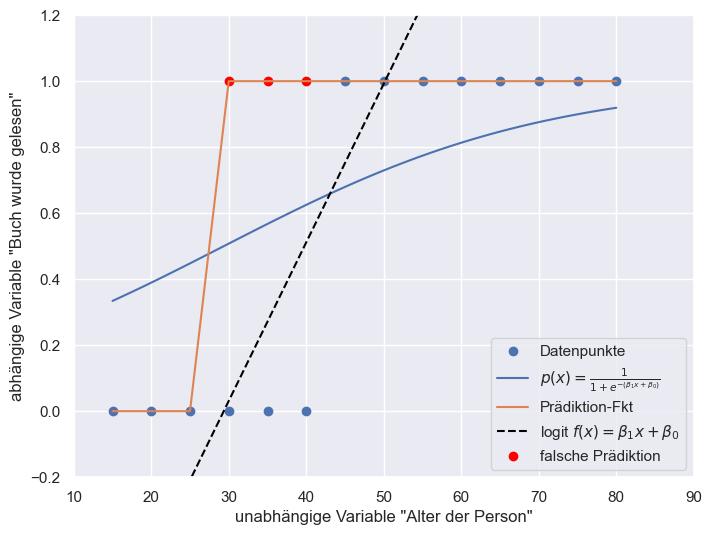

In [18]:
plt.figure(figsize=(8,6))

# Daten
plt.scatter(Alter,Gelesen,label='Datenpunkte')

# Wahrscheinlichkeitsfunktion
X_tmp = np.linspace(X.min(),X.max()).reshape(-1,1)
label=r'$p(x)=\frac{1}{1+e^{-(\beta_1 x + \beta_0)}}$'
plt.plot(X_tmp,LogisticReg_model.predict_proba(X_tmp)[:,1],label=label)

# Prädiktion des Modells
plt.plot(X,LogisticReg_model.predict(X),label='Prädiktion-Fkt')

# logit
logit = LogisticReg_model.intercept_ + LogisticReg_model.coef_*X
label = r'logit $f(x) = \beta_1 x + \beta_0$'
plt.plot(X,logit,color='black', ls='--', label=label)

# Einzeichnen der falsch prädizierten Werte in rot
idx = y!=LogisticReg_model.predict(X)
plt.scatter(X[idx],LogisticReg_model.predict(X[idx]),color='red',label='falsche Prädiktion')

plt.xlim(10,90)
plt.ylim(-0.2,1.2)
plt.legend(loc='lower right')
plt.xlabel('unabhängige Variable "Alter der Person"')
plt.ylabel('abhängige Variable "Buch wurde gelesen"');

### Berechnung der Confusion Matrix und des Classifikation reports

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [20]:
cm = confusion_matrix(y, LogisticReg_model.predict(X))
cm

array([[3, 3],
       [0, 8]])

#### Plotten der Confusion Matrix mit `ConfusionMatrixDisplay`

Mit [`sklearn.metrics.ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) wird im folgenden auf drei verschienden Weise, die Confusion Matrix als ein Heatmap-Plot dargestellt:
- Möglichkeit 1: confusion matrix liegt vor
- Möglichkeit 2: Modell (Schätzer/Estimator) liegt vor; Datensatz (Test-Datensatz) wird für die Berechnung benötigt
- Möglichkeit 3: Prädizierte Ausgangswerte liegen vor; es werden noch die wahren Ausgangswerte dazu benötigt

_**Möglichkeit 1**_: confusion matrix liegt vor

Instanz der [`sklearn.metrics.ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)-Klasse erstellen und mit der [.plot()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.plot)-Methode den Plot der Confusion Matrix erzeugen.

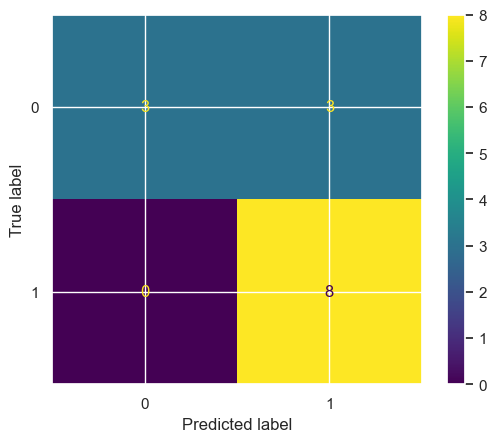

In [21]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LogisticReg_model.classes_)
disp.plot()

_**Möglichkeit 2**_: Modell (Schätzer/Estimator) liegt vor; Datensatz (Test-Datensatz) wird für die Berechnung benötigt

[`.from_estimator()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_estimator)-Methode:
- 1. Parameter: Modell welches an die Traingsdaten angepasst wurde
- 2. und 3. Parameter: Daten für die die Conflusion Matrix berechnet werden soll 

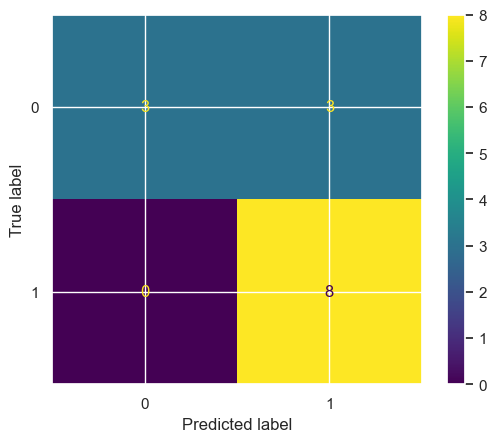

In [22]:
ConfusionMatrixDisplay.from_estimator(LogisticReg_model, X, y)

_**Möglichkeit 3**_: Prädizierte Ausgangswerte liegen vor; es werden noch die wahren Ausgangswerte dazu benötigt

[`.from_predictions()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_predictions)-Methode:
- 1. Parameter wahre Ausgangswerte (true targets)
- 2. Parameter prädizierte Ausgangswerte (predicted targts)

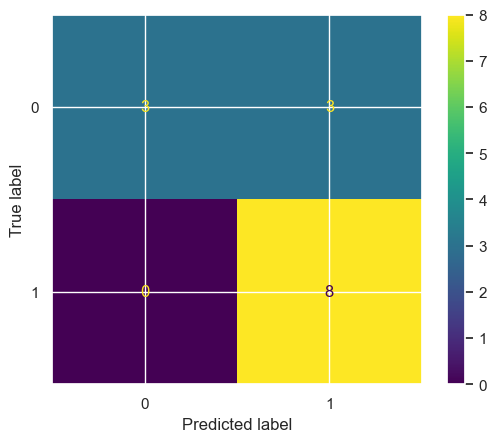

In [23]:
y_pred = LogisticReg_model.predict(X)
ConfusionMatrixDisplay.from_predictions(y, y_pred)

#### Classification report

In [24]:
print(classification_report(y, LogisticReg_model.predict(X)))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.73      1.00      0.84         8

    accuracy                           0.79        14
   macro avg       0.86      0.75      0.75        14
weighted avg       0.84      0.79      0.77        14



---
### Modell verbessern - Abstimmen der Hyperparameter

Hyperparameter C : float, default=1.0
    Inverse of regularization strength; must be a positive float.
    <br>
    Like in support vector machines, smaller values specify stronger
    regularization.

weitere Werte für C:
- C=10.0
- C=100.0

In [25]:
LogisticReg_model2 = LogisticRegression(solver='liblinear', C=100.0, random_state=0)
LogisticReg_model2.fit(X, y)
print(f'Score: {LogisticReg_model2.score(X,y)}')
print(f'confusion_matrix: \n {confusion_matrix(y, LogisticReg_model2.predict(X))}')
print(classification_report(y, LogisticReg_model2.predict(X)))

Score: 1.0
confusion_matrix: 
 [[6 0]
 [0 8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         8

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



### Umschaltpunkt bestimmen:

Bedingung _**logit**_  $f(x) =0$:
$$
    f(x) = \beta_1 x + \beta_0 \quad \Rightarrow \quad x_{\text{threshold}}= \frac{-\beta_0}{\beta_1}
$$

In [26]:
threshold =  -LogisticReg_model2.intercept_/ LogisticReg_model2.coef_
np.squeeze(threshold)

array(41.93209276)

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
C:\Users\guecker\AppData\Local\Temp\ipykernel_7560\3412447886.py:22: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X,LogisticReg_model.predict(X),label='Prädiktion-Fkt $\sigma(p(x)-0.5)$')


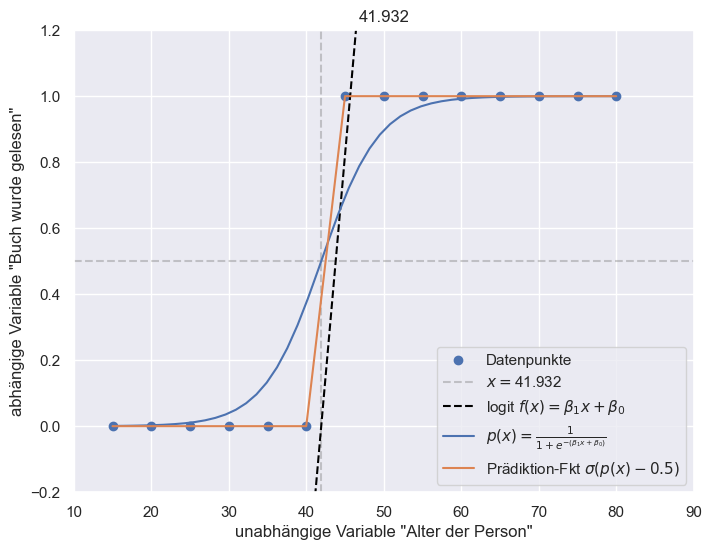

In [27]:
def plot_logistic_regression(LogisticReg_model,X,y):
    plt.figure(figsize=(8,6))


    plt.scatter(Alter,Gelesen,label='Datenpunkte')

    threshold =  np.squeeze(-LogisticReg_model.intercept_/ LogisticReg_model.coef_)
    plt.title(f'{threshold:.3f}')
    
    kwargs = dict(color='grey',ls='--',alpha=0.4)
    plt.axhline(0.5,**kwargs)
    plt.axvline(threshold,**kwargs,label=f'$x=${threshold:.3f}')
    
    logit = LogisticReg_model.intercept_ + LogisticReg_model.coef_*X
    label = r'logit $f(x) = \beta_1 x + \beta_0$'
    plt.plot(X,logit,color='black', ls='--', label=label)

    
    X_tmp = np.linspace(X.min(),X.max()).reshape(-1,1)
    label=r'$p(x)=\frac{1}{1+e^{-(\beta_1 x + \beta_0)}}$'
    plt.plot(X_tmp,LogisticReg_model.predict_proba(X_tmp)[:,1],label=label)
    plt.plot(X,LogisticReg_model.predict(X),label='Prädiktion-Fkt $\sigma(p(x)-0.5)$')

    
       
    idx = y!=LogisticReg_model.predict(X)
    if any(idx):
        plt.scatter(X[idx],LogisticReg_model.predict(X[idx]),color='red',label='falsche Prädiktion')

    plt.xlim(10,90)
    plt.ylim(-0.2,1.2)
    plt.legend(loc='lower right')
    plt.xlabel('unabhängige Variable "Alter der Person"')
    plt.ylabel('abhängige Variable "Buch wurde gelesen"');
# ---------------------------------
plot_logistic_regression(LogisticReg_model2,X,y)


----
### Daten mit einem 'Ausreißer'

Ein Zwanzigjähriger hat das Buch gelesen.

In [28]:
Alter   = [15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]
Gelesen = [ 0,  1,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1]

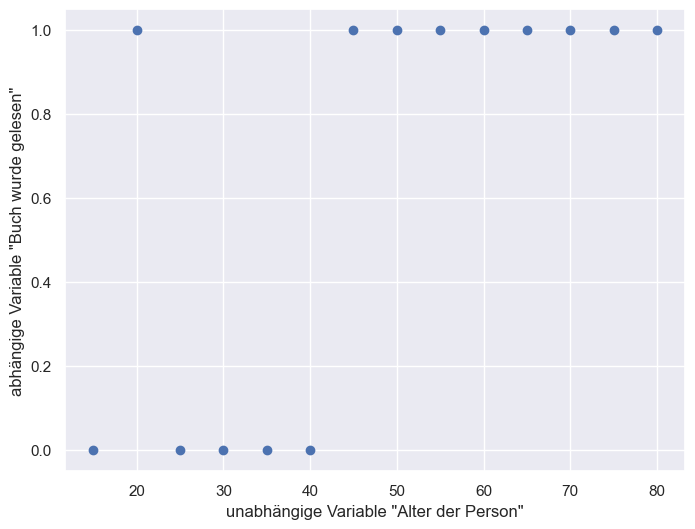

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(Alter,Gelesen)
plt.xlabel('unabhängige Variable "Alter der Person"')
plt.ylabel('abhängige Variable "Buch wurde gelesen"');

In [30]:
def Model_fit(Alter,Gelesen,C=1.0):
    df = pd.DataFrame(data={'Alter':Alter,'Gelesen':Gelesen})
    X = df[['Alter']].values  # erstellt einen DataFrame nur mit der Spalte 'Alter'
    y = df['Gelesen'].values
    LogisticReg_model = LogisticRegression(solver='liblinear', C=C, random_state=0)
    LogisticReg_model.fit(X, y)
    print(f'Score: {LogisticReg_model.score(X,y)}')
    print(f'confusion_matrix: \n {confusion_matrix(y, LogisticReg_model.predict(X))}')
    print(classification_report(y, LogisticReg_model.predict(X)))
    plot_logistic_regression(LogisticReg_model,X,y)

Score: 0.8571428571428571
confusion_matrix: 
 [[4 1]
 [1 8]]
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.89      0.89      0.89         9

    accuracy                           0.86        14
   macro avg       0.84      0.84      0.84        14
weighted avg       0.86      0.86      0.86        14



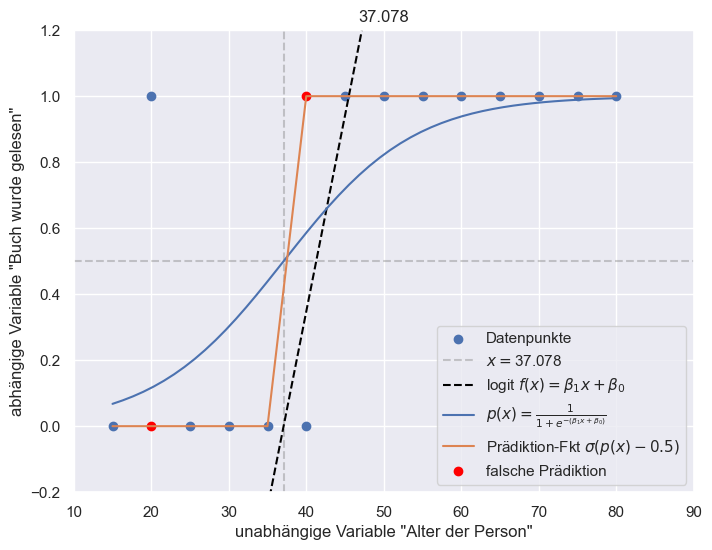

In [31]:
Model_fit(Alter,Gelesen,C=1000.0)